### Distributed Computing
### Group Project
### Tianyi Luo (Alex)

Import Packages

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
import os
import pyspark
from math import sqrt

sc = pyspark.SparkContext().getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/02 17:04:31 WARN Utils: Your hostname, Tianyis-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.41.241.176 instead (on interface en0)
25/12/02 17:04:31 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/02 17:04:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Which industries rely most on accruals, and do those industries show more volatile earnings?

In accounting, accruals are the part of earnings that does not come from actual cash this period.

Accruals ≈ Accounting earnings − Cash flow from operations   

Examples:

You record revenue now but customer pays you next year → accounts receivable = positive accrual.

You record expense now but pay cash later → accounts payable, depreciation, provisions = also accruals.

So if accruals are large, it means:

Reported profit is heavily driven by estimates, timing adjustments, and accounting rules,

And less tied to real cash coming in and out.

In [5]:
import argparse

parser = argparse.ArgumentParser()
parser.add_argument(
    "--is-local",
    type=str,
    default="true",
    help="Whether running in local mode",
)

args, unknown = parser.parse_known_args()
is_local = args.is_local.lower() == "true"
if is_local:
    #prefix = "../data/processed/merged"
    # from alex_luo.ipynb, go *down* into the repo folder then into data/processed/merged
    prefix = "Distributed_computing_group_project/data/processed/merged"
else:
    prefix = "gs://msds-694-cohort-14-3/data"

print(f"Is local environment: {is_local}")

num_csv_path = f"{prefix}/num_2020.csv"
pre_csv_path = f"{prefix}/pre_2020.csv"
sub_csv_path = f"{prefix}/sub_2020.csv"
tag_csv_path = f"{prefix}/tag_2020.csv"

print(f"Num CSV path: {num_csv_path}")
print(f"Pre CSV path: {pre_csv_path}")
print(f"Sub CSV path: {sub_csv_path}")
print(f"Tag CSV path: {tag_csv_path}")

num_rdd = sc.textFile(num_csv_path)
pre_rdd = sc.textFile(pre_csv_path)
sub_rdd = sc.textFile(sub_csv_path)
tag_rdd = sc.textFile(tag_csv_path)

# print size of each RDD
print(f"Num RDD size: {num_rdd.count()}")
print(f"Pre RDD size: {pre_rdd.count()}")
print(f"Sub RDD size: {sub_rdd.count()}")
print(f"Tag RDD size: {tag_rdd.count()}")

Is local environment: True
Num CSV path: Distributed_computing_group_project/data/processed/merged/num_2020.csv
Pre CSV path: Distributed_computing_group_project/data/processed/merged/pre_2020.csv
Sub CSV path: Distributed_computing_group_project/data/processed/merged/sub_2020.csv
Tag CSV path: Distributed_computing_group_project/data/processed/merged/tag_2020.csv


Num RDD size: 11493263
Pre RDD size: 2746310
Sub RDD size: 24940
Tag RDD size: 298803


In [6]:
num_header_line = num_rdd.first()
sub_header_line = sub_rdd.first()

num_header = num_header_line.split(",")
sub_header = sub_header_line.split(",")

num_body = (num_rdd.filter(lambda x: x != num_header_line)\
            .map(lambda x: x.split(","))\
            .filter(lambda x: len(x) == len(num_header)))

sub_body = (sub_rdd.filter(lambda x: x != sub_header_line)\
            .map(lambda x: x.split(","))\
            .filter(lambda x: len(x) == len(sub_header)))

In [7]:
n_adsh  = num_header.index("adsh")
n_tag   = num_header.index("tag")
n_uom   = num_header.index("uom")
n_seg   = num_header.index("segments")
n_coreg = num_header.index("coreg")
n_val   = num_header.index("value")
s_adsh  = sub_header.index("adsh")
s_sic   = sub_header.index("sic")

### The tag we need（NI / OCF / Assets）

In [11]:
# Tags we need for the accrual ratio:
#   Net Income, Operating Cash Flow, Total Assets
accrual_tags = {
    "NetIncomeLoss",
    "NetCashProvidedByUsedInOperatingActivities",
    "NetCashProvidedByUsedInOperatingActivitiesContinuingOperations",
    "Assets",
}

# Keep only USD, consolidated, no co-registrant, non-empty value
num_filtered = (
    num_body
    .filter(lambda x: (
        x[n_tag] in accrual_tags and
        x[n_uom] == "USD" and
        x[n_seg] == "" and
        x[n_coreg] == "" and
        x[n_val] != ""
    ))
)


### Turn NUM into (adsh, tag, value)，create RDD

In [12]:
def safe_float(s):
    try:
        return float(s)
    except Exception:
        return None

# (adsh, tag, value)
num_tag_val = (
    num_filtered
    .map(lambda x: (x[n_adsh], x[n_tag], safe_float(x[n_val])))
    .filter(lambda x: x[2] is not None)
)

# Net income per filing
ni_rdd = (
    num_tag_val
    .filter(lambda x: x[1] == "NetIncomeLoss")
    .map(lambda x: (x[0], x[2]))
)

# Operating cash flow: there may be multiple related tags, we sum them
ocf_candidates = (
    num_tag_val
    .filter(lambda x: x[1] in {
        "NetCashProvidedByUsedInOperatingActivities",
        "NetCashProvidedByUsedInOperatingActivitiesContinuingOperations",
    })
    .map(lambda x: (x[0], x[2]))
)

ocf_rdd = ocf_candidates.reduceByKey(lambda a, b: a + b)

# Total assets per filing
assets_rdd = (
    num_tag_val
    .filter(lambda x: x[1] == "Assets")
    .map(lambda x: (x[0], x[2]))
)


### For every filing, calculate accrual ratio and earnings/assets

Accruals = (NetIncome – OperatingCashFlow) / TotalAssets

In [ ]:
# Join Net Income, Operating Cash Flow and Assets at the filing (adsh) level
ni_ocf = ni_rdd.join(ocf_rdd)              # (adsh, (ni, ocf))
filing_raw = ni_ocf.join(assets_rdd)      # (adsh, ((ni, ocf), assets))

# Flatten and drop cases with non-positive assets
# (adsh, ni, ocf, assets)
filing_metrics = (
    filing_raw
    .map(lambda x: (x[0], x[1][0][0], x[1][0][1], x[1][1]))
    .filter(lambda x: x[3] > 0)
)

# (adsh, (accrual_ratio, earnings_to_assets))
# accrual_ratio = (NI - OCF) / Assets
# earnings_to_assets = NI / Assets  (simple earnings level)
accruals_rdd = filing_metrics.map(
    lambda x: (
        x[0],
        (
            (x[1] - x[2]) / x[3],
            x[1] / x[3],
        )
    )
)

### connect industry (SIC)，aggregate by industry：average accrual + earnings volatility

use earnings/assets std as earnings volatility

NUM – numeric line items

Each row = one number in the financial statements (e.g., NetIncomeLoss, Assets)

Key: adsh (accession number → specific filing)

SUB – submission info

Each row = one filing (10-K/10-Q)

Contains: adsh, cik, sic (industry code), company name, etc.

In [32]:
# Build (adsh, sic) pairs from SUB
sub_pairs = (
    sub_body
    .filter(lambda x: x[s_sic] != "")
    .map(lambda x: (x[s_adsh], str(int(float(x[s_sic])))))
)

# Join accruals with SIC
# (adsh, ((accrual_ratio, earnings_to_assets), sic))
accruals_with_sic = accruals_rdd.join(sub_pairs)

# (sic, (accrual_ratio, earnings_to_assets))
sic_accrual_pairs = accruals_with_sic.map(
    lambda x: (x[1][1], x[1][0])
)

from math import sqrt

# For each SIC, aggregate:
#   sum_accr, sum_accr2, sum_earn, sum_earn2, count
def create_stats(v):
    accr, earn = v
    return (accr, accr * accr, earn, earn * earn, 1)

def merge_stats(acc, v):
    accr, earn = v
    return (
        acc[0] + accr,
        acc[1] + accr * accr,
        acc[2] + earn,
        acc[3] + earn * earn,
        acc[4] + 1,
    )

def merge_combine(a, b):
    return (
        a[0] + b[0],
        a[1] + b[1],
        a[2] + b[2],
        a[3] + b[3],
        a[4] + b[4],
    )

sic_stats_raw = sic_accrual_pairs.combineByKey(
    create_stats, merge_stats, merge_combine
)

# Map to structure with mean + volatility
# earnings_volatility = std of (NI / Assets) within each industry
sic_stats = sic_stats_raw.mapValues(
    lambda x: {
        "avg_accrual": x[0] / x[4],
        "avg_earnings": x[2] / x[4],
        "earnings_volatility": sqrt(
            max(x[3] / x[4] - (x[2] / x[4]) ** 2, 0.0)
        ),
        "n_filings": x[4],
    }
)


In [ ]:
sic_stats.take(5)

[('2842',
  {'avg_accrual': -0.3852794427742603,
   'avg_earnings': 0.07881565088573037,
   'earnings_volatility': 0.0533017350479328,
   'n_filings': 109}),
 ('4911',
  {'avg_accrual': -0.11328732527613262,
   'avg_earnings': 0.008570772499856808,
   'earnings_volatility': 0.021327889578261604,
   'n_filings': 1059}),
 ('3578',
  {'avg_accrual': 0.09458295795117126,
   'avg_earnings': -0.05395723024645206,
   'earnings_volatility': 0.06518585734179666,
   'n_filings': 179}),
 ('3480',
  {'avg_accrual': -0.2722713306609494,
   'avg_earnings': 0.049511200410522704,
   'earnings_volatility': 0.0409954557121455,
   'n_filings': 136}),
 ('2100',
  {'avg_accrual': 0.055461911156225695,
   'avg_earnings': -0.1840607738348392,
   'earnings_volatility': 0.22439904366480085,
   'n_filings': 24})]

Read SIC lookup, join with stats

In [31]:
if is_local:
    # alex_luo.ipynb and SIC_Lookup.csv are in the same folder
    sic_lookup_path = "SIC_Lookup.csv"
else:
    # On Dataproc, Ignacio will likely place this in the data bucket.
    # Adjust if he uses a slightly different path.
    sic_lookup_path = "gs://msds-694-cohort-14-3/data/SIC_Lookup.csv"

print("SIC lookup path:", sic_lookup_path)

# Load SIC lookup as (sic, industry_name)
sic_lookup_rdd = (
    sc.textFile(sic_lookup_path)
    .map(lambda x: x.split(","))                # simple CSV split
    .filter(lambda x: len(x) >= 2 and x[0] != "sic")  # skip header
    .map(lambda x: (x[0], x[1]))               # (sic, industry_name)
)

print("Example SIC lookup rows:", sic_lookup_rdd.take(5))

# Join stats with industry names
# sic_stats: (sic, stats_dict)
# sic_lookup_rdd: (sic, industry_name)
sic_stats_named = sic_stats.join(sic_lookup_rdd)
# (sic, (stats_dict, industry_name))

# Flatten to: (sic, avg_accrual, earnings_volatility, n_filings, industry_name)
sic_named_flat = sic_stats_named.map(
    lambda x: (
        x[0],                              # sic code
        x[1][0]["avg_accrual"],            # average accrual ratio
        x[1][0]["earnings_volatility"],    # std of earnings/asset
        x[1][0]["n_filings"],              # number of filings
        x[1][1],                           # industry name
    )
)

# sample size >= 10 filings
sic_named_filtered = sic_named_flat.filter(lambda x: x[3] >= 10)

print("Sample of industry-level stats:", sic_named_filtered.take(5))


SIC lookup path: SIC_Lookup.csv
Example SIC lookup rows: [('SIC', 'Industry'), ('100', 'AGRICULTURAL PRODUCTION-CROPS'), ('200', 'AGRICULTURAL PROD-LIVESTOCK & ANIMAL SPECIALTIES'), ('700', 'AGRICULTURAL SERVICES'), ('800', 'FORESTRY')]


Sample of industry-level stats: [('2082', -0.10494930395594876, 0.38756339959591274, 122, 'MALT BEVERAGES'), ('2320', -0.15795747690773532, 0.047491631142716095, 212, '"MEN\'S & BOYS\' FURNISHGS'), ('2030', -0.09621899170116531, 0.2756744961432785, 115, '"CANNED'), ('8000', -0.16438978533623358, 0.021347977082525754, 34, 'SERVICES-HEALTH SERVICES'), ('3334', -0.06662902739004456, 0.023024296032313596, 92, 'PRIMARY PRODUCTION OF ALUMINUM')]


visualization: industries with highest accruals

/var/folders/5f/vq31x3ws3756twnm7dl48s3m0000gn/T/ipykernel_2260/4281236191.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


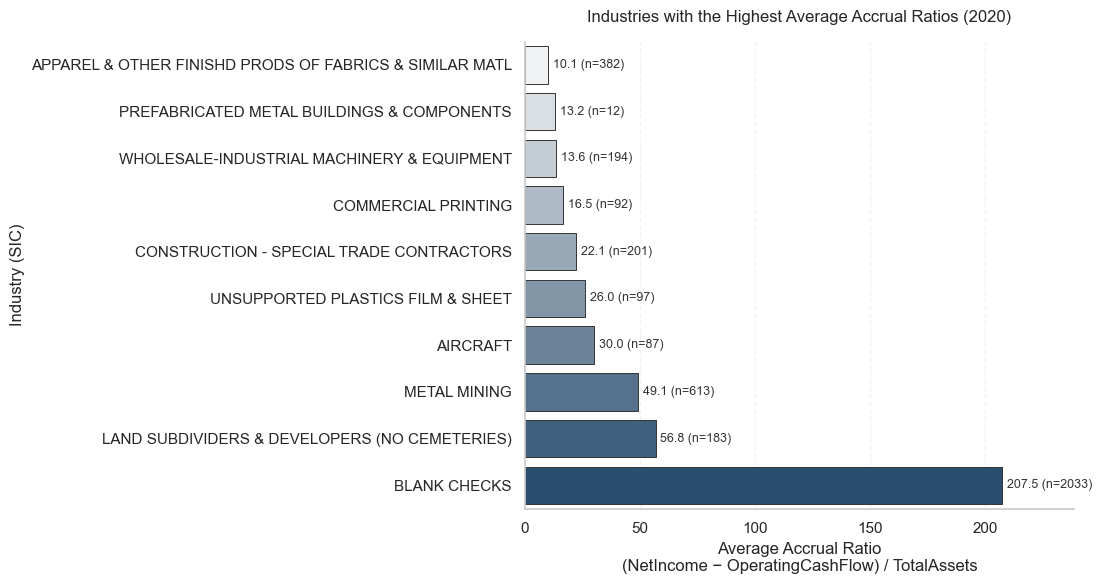

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

top_accrual = sic_named_filtered.sortBy(lambda x: x[1], ascending=False).take(10)

cols = ["sic", "avg_accrual", "earnings_volatility", "n_filings", "industry"]
df_accrual = (
    pd.DataFrame(top_accrual, columns=cols)
    .sort_values("avg_accrual")   
)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Georgia", "DejaVu Serif", "Times New Roman"],
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

sns.set_theme(style="whitegrid")

df_plot = df_accrual.copy()

# Keep industries ordered from lowest to highest accrual (for barh)
df_plot = df_plot.sort_values("avg_accrual")

# Build a smooth blue palette, lighter to darker
palette = sns.light_palette("#1f4e79", n_colors=len(df_plot))

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=df_plot,
    x="avg_accrual",
    y="industry",
    palette=palette,
    edgecolor="#333333",
    linewidth=0.7,
    ax=ax,
)

# title
ax.set_xlabel("Average Accrual Ratio\n(NetIncome − OperatingCashFlow) / TotalAssets")
ax.set_ylabel("Industry (SIC)")
ax.set_title("Industries with the Highest Average Accrual Ratios (2020)", pad=14)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.grid(axis="y", visible=False)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Annotate each bar with value and n on the right side
for i, (val, n) in enumerate(zip(df_plot["avg_accrual"], df_plot["n_filings"])):
    ax.text(
        val + max(df_plot["avg_accrual"]) * 0.01,  # small offset to the right
        i,
        f"{val:.1f} (n={int(n)})",
        va="center",
        ha="left",
        fontsize=9,
        color="#333333",
    )

xmax = df_plot["avg_accrual"].max()
ax.set_xlim(0, xmax * 1.15)

plt.tight_layout()
plt.show()


“BLANK CHECKS” is an industry category.

In the SIC system there is a code for “Blank Checks”. It refers to blank check companies, which are basically:

Shell companies that go public with no specific operating business yet,

They raise cash first and later look for a target to merge with (similar to SPACs).

Interpretation

In 2020, the industry that relies most heavily on accruals is BLANK CHECKS, with an average accrual ratio of roughly 207% of total assets, based on more than 3,000 filings. This is far above the next highest industries, such as LAND SUBDIVIDERS & DEVELOPERS (NO CEMETERIES) (~57%) and METAL MINING (~49%), where accruals are still large but much closer to each other. 

In these sectors, reported earnings are driven much more by accrual adjustments than by operating cash flows. Combined with the earnings-volatility numbers (standard deviation of NI/Assets), many of these high-accrual industries also show relatively unstable earnings, which is consistent with the idea that heavy use of accruals is associated with more volatile, less “cash-anchored” profitability.